In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.describe(include="object")

/tmp/ipykernel_818/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


## Data Exploration using Pandas

In [9]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
df.isnull().mean() * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

### Unique values & value counts

In [12]:
df["pclass"].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [13]:
df["sex"].value_counts(normalize=True)

sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [14]:
df["embark_town"].unique()

<ArrowStringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

### Selecting & filtering

In [15]:
df[["sex", "age", "survived"]]

,sex,age,survived
0,male,22.0,0
1,female,38.0,1
2,female,26.0,1
3,female,35.0,1
4,male,35.0,0
...,...,...,...
886,male,27.0,0
887,female,19.0,1
888,female,NaN,0
889,male,26.0,1


In [16]:
df[df["age"] > 60]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
170,0,1,male,61.0,0,0,33.5000,S,First,man,True,B,Southampton,no,True
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,C,Southampton,no,True
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,D,Southampton,yes,False
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,NaN,Southampton,no,True
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,C,Southampton,no,False


In [17]:
df[(df["pclass"] == 1) & (df["survived"] == 1)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,1,1,female,48.0,0,0,25.9292,S,First,woman,False,D,Southampton,yes,True
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [18]:
df.loc[df["sex"] == 'female', ["age", "fare"]]

,age,fare
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
8,27.0,11.1333
9,14.0,30.0708
...,...,...
880,25.0,26.0000
882,22.0,10.5167
885,39.0,29.1250
887,19.0,30.0000


In [19]:
df.iloc[0:5, 1:4]

,pclass,sex,age
0,3,male,22.0
1,1,female,38.0
2,3,female,26.0
3,1,female,35.0
4,3,male,35.0


## Handling Missing Data

In [20]:
df["age"] = df["age"].fillna(df["age"].median())

In [21]:
df["age"].isnull().sum()

np.int64(0)

In [22]:
df["embarked"].isnull().sum()

np.int64(2)

In [23]:
df["embarked"].mode()[0]

'S'

In [24]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [25]:
df["embark_town"].isnull().sum()

np.int64(2)

In [26]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [27]:
df = df.drop(columns=["deck"])

In [28]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## GroupBy & Aggregation

In [29]:
df.groupby('pclass')["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [30]:
df.groupby(["sex", "pclass"])["survived"].mean().unstack()

pclass,1,2,3
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [31]:
# Multiple aggregations

df.groupby("pclass").agg(
    avg_age=("age", "mean"),
    avg_fare=("fare", "mean"),
    survival_rate=("survived", "mean"),
    count=("survived", "size"),
)

,avg_age,avg_fare,survival_rate,count
pclass,,,,
1,36.812130,84.154687,0.629630,216
2,29.765380,20.662183,0.472826,184
3,25.932627,13.675550,0.242363,491


## Feature Engineering

In [32]:
# Family size
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [33]:
# Age bins
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                          labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

In [34]:
df['fare_group'] = pd.qcut(df['fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])


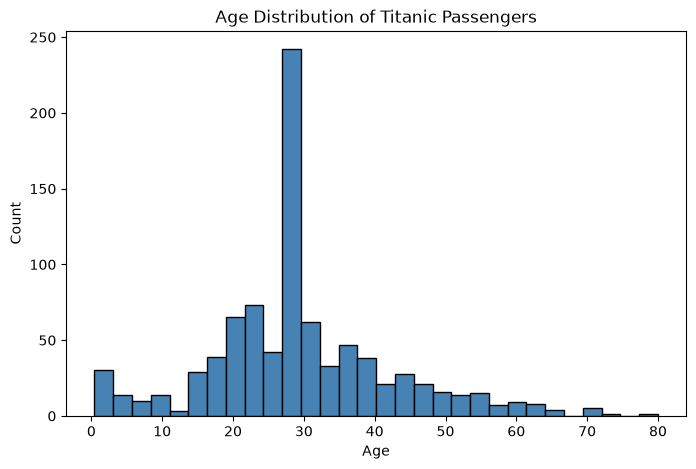

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

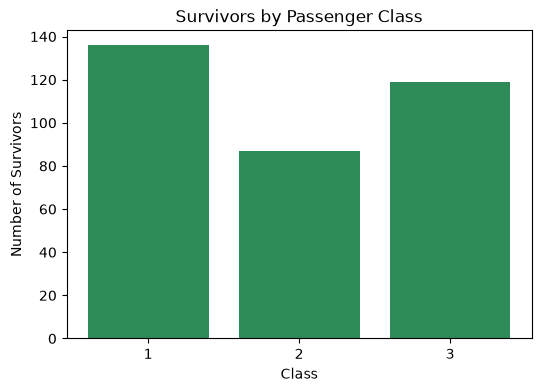

In [36]:
survival_by_class = df.groupby('pclass')['survived'].sum()

plt.figure(figsize=(6, 4))
plt.bar(survival_by_class.index.astype(str), survival_by_class.values, color='seagreen')
plt.title('Survivors by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Number of Survivors')
plt.show()